In [ ]:
####-Rushda Qureshi-msbwe2-2503951
###Lab coding

In [2]:
###load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Load the dataset
# Specifying na_values=["?"] handles cases where '?' is used for missing data
df = pd.read_csv('heart-2.csv', na_values=["?"])

In [4]:
# 2. Check for missing values and duplicates
print("Missing values per column:\n", df.isna().sum())
df = df.drop_duplicates()
print(f"\nTotal records after removing duplicates: {len(df)}")

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total records after removing duplicates: 302


In [5]:
# 3. Imputation
# Categorical variables use mode, numerical use median
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])

In [6]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [8]:
# 4. Map categorical codes to labels for interpretability
df_clean = df.copy()
mapping = {
    'cp': {0: 'typical angina', 1: 'atypical angina', 2: 'non-anginal pain', 3: 'asymptomatic'},
    'sex': {1: 'male', 0: 'female'},
    'restecg': {0: 'normal', 1: 'ST-T wave abnormality', 2: 'LV hypertrophy'},
    'slope': {0: 'upsloping', 1: 'flat', 2: 'downsloping'},
    'thal': {1: 'normal', 2: 'fixed defect', 3: 'reversable defect'},
    'target': {1: 'heart disease', 0: 'no disease'}
}

for col, labels in mapping.items():
    df_clean[col] = df_clean[col].map(labels)

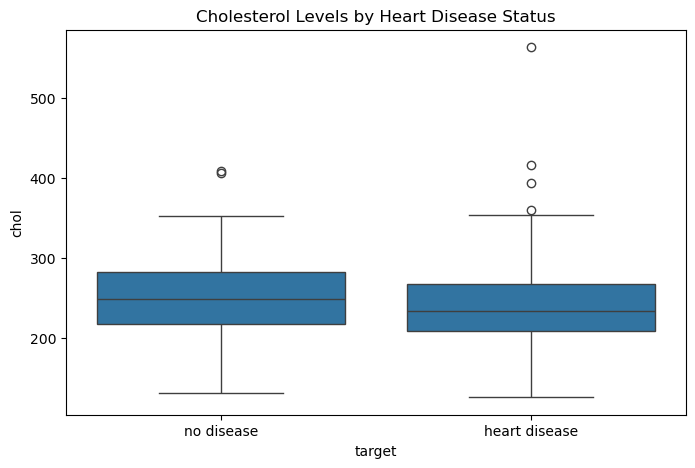

In [9]:
# 5. Exploratory Observations
# Plot 1: Cholesterol vs Target
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='chol', data=df_clean)
plt.title('Cholesterol Levels by Heart Disease Status')
plt.savefig('chol_by_target.png')

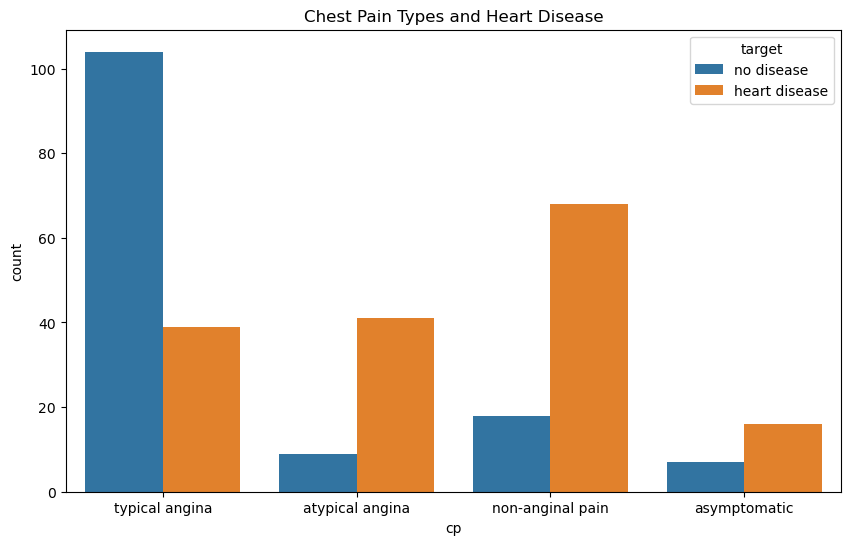

In [10]:
# Plot 2: Chest Pain Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='cp', hue='target', data=df_clean)
plt.title('Chest Pain Types and Heart Disease')
plt.savefig('cp_vs_target.png')

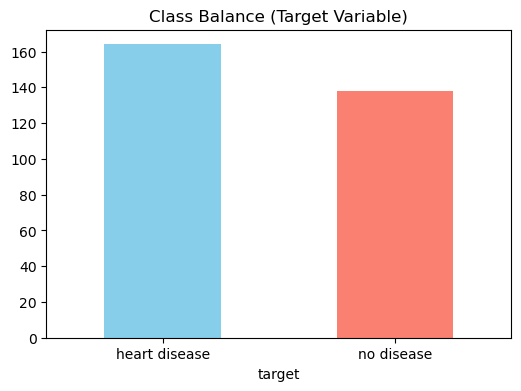

In [11]:
# Plot 3: Class Balance
plt.figure(figsize=(6, 4))
df_clean['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Balance (Target Variable)')
plt.xticks(rotation=0)
plt.savefig('class_balance.png')

In [12]:
# 6. Separate Target and Features
y = df['target']
X = df.drop(columns=['target'])

In [13]:
print("\n--- Processed Features Shape ---")
print(X.shape)



--- Processed Features Shape ---
(302, 13)


In [14]:
# 6. Final Data Preparation and Export
# Separate features and target
y = df['target']
X = df.drop(columns=['target'])

In [15]:
#Export cleaned data (Note: Path adjusted to current directory)
output_path = 'heart_disease_cleaned.csv' 
df.to_csv(output_path, index=False)
print(f"Cleaned dataset exported to {output_path}")

Cleaned dataset exported to heart_disease_cleaned.csv


In [ ]:
###3-Question/answer
##-1-Why is it important to map numeric categorical codes to labels before modelling?
##-- By usiing the labels, experts can relationships model discovered align with the literature review to ensure the model is making the right decisions.
##-2-How might outliers in cholesterol levels impact model training and performance?
##-- In decision based algorithims KNN high cholestrol value can dominate the distance calculation causing the model to misclassify normal casses because it was over sensitive to the extreme value.